In [ ]:
# Importando las dependencias 
import time
import joblib
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, RobustScaler, TargetEncoder
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error, mean_absolute_percentage_error

**Lectura del Dataset y realizando una copia**

In [45]:
df = pd.read_csv("vehicles.csv")
df_copy = df.copy()
df_copy.head()

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


### Obteniendo intuiciones del dataset

In [3]:
df_copy.shape

(426880, 26)

In [5]:
df_copy.info()

<class 'pandas.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  str    
 2   region        426880 non-null  str    
 3   region_url    426880 non-null  str    
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  str    
 7   model         421603 non-null  str    
 8   condition     252776 non-null  str    
 9   cylinders     249202 non-null  str    
 10  fuel          423867 non-null  str    
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  str    
 13  transmission  424324 non-null  str    
 14  VIN           265838 non-null  str    
 15  drive         296313 non-null  str    
 16  size          120519 non-null  str    
 17  type          334022 non-null  str    
 18  paint_color   2

In [7]:
df_copy.describe()

,id,price,year,odometer,county,lat,long
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05,0.0,420331.000000,420331.000000
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04,NaN,38.493940,-94.748599
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05,NaN,5.841533,18.365462
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00,NaN,-84.122245,-159.827728
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04,NaN,34.601900,-111.939847
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04,NaN,39.150100,-88.432600
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05,NaN,42.398900,-80.832039
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07,NaN,82.390818,173.885502


In [11]:
df_copy.isnull().any()

id              False
url             False
region          False
region_url      False
price           False
year             True
manufacturer     True
model            True
condition        True
cylinders        True
fuel             True
odometer         True
title_status     True
transmission     True
VIN              True
drive            True
size             True
type             True
paint_color      True
image_url        True
description      True
county           True
state           False
lat              True
long             True
posting_date     True
dtype: bool

In [46]:
df_copy.isnull().sum()

id                   0
url                  0
region               0
region_url           0
price                0
year              1205
manufacturer     17646
model             5277
condition       174104
cylinders       177678
fuel              3013
odometer          4400
title_status      8242
transmission      2556
VIN             161042
drive           130567
size            306361
type             92858
paint_color     130203
image_url           68
description         70
county          426880
state                0
lat               6549
long              6549
posting_date        68
dtype: int64

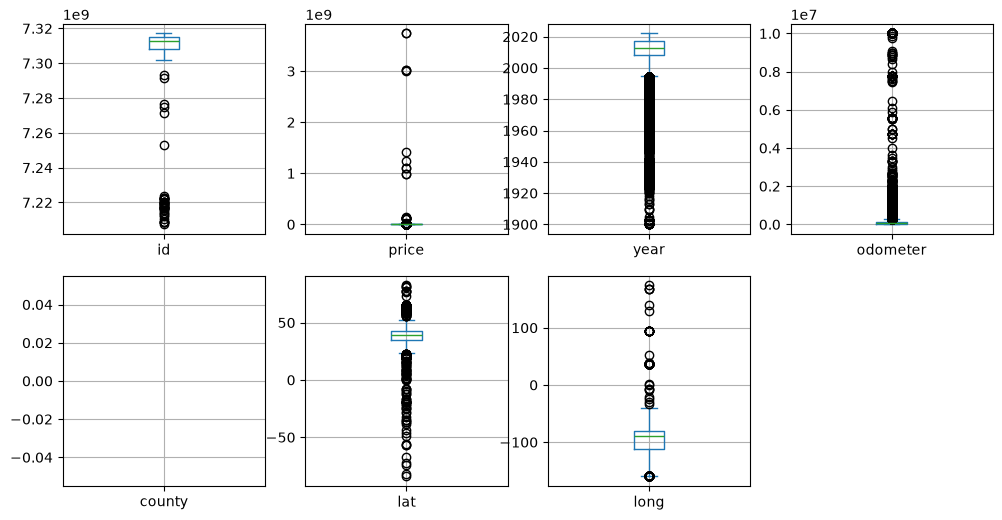

In [48]:
column_num = df_copy.select_dtypes(include=[int, float])
column_num.plot(kind="box", subplots=True, layout=(2, 4), grid=True, figsize=(12, 6))
plt.show()

### Mostrando los valores de las variables categoricas, eliminando las inrelevantes

In [55]:
df_copy.info()

<class 'pandas.DataFrame'>
Index: 60631 entries, 32 to 426878
Data columns (total 24 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            60631 non-null  int64  
 1   url           60631 non-null  str    
 2   region        60631 non-null  str    
 3   region_url    60631 non-null  str    
 4   price         60631 non-null  int64  
 5   year          60631 non-null  float64
 6   manufacturer  60631 non-null  str    
 7   model         60631 non-null  str    
 8   condition     60631 non-null  str    
 9   cylinders     60631 non-null  str    
 10  fuel          60631 non-null  str    
 11  odometer      60631 non-null  float64
 12  title_status  60631 non-null  str    
 13  transmission  60631 non-null  str    
 14  VIN           60631 non-null  str    
 15  drive         60631 non-null  str    
 16  type          60631 non-null  str    
 17  paint_color   60631 non-null  str    
 18  image_url     60631 non-null  str    
 1

In [77]:
df_copy["state"].value_counts()

state
ca    6823
fl    4776
ny    3318
tx    2865
oh    2386
mi    2282
nc    2278
pa    2077
wi    2047
ia    1988
va    1718
tn    1505
ma    1449
ok    1426
or    1403
nj    1396
il    1377
in    1314
mn    1261
ks    1133
co    1096
az    1059
sc     955
ky     937
vt     927
ga     814
mo     795
al     772
id     771
ct     734
ak     620
wa     539
md     520
nm     511
mt     482
ar     480
dc     391
nv     391
ri     373
la     366
nh     307
hi     306
me     301
de     208
ut     202
wv     198
sd     186
ne     181
nd     138
ms     125
wy     124
Name: count, dtype: int64

In [74]:
df_copy["posting_date"].value_counts()

posting_date
2021-04-23T22:13:05-0400    12
2021-04-13T13:19:15-0500    11
2021-04-16T12:07:56-0500    10
2021-04-29T20:06:09-0500     9
2021-05-03T20:46:03-0700     8
                            ..
2021-04-05T03:30:19-0600     1
2021-04-05T03:20:23-0600     1
2021-04-05T02:41:26-0600     1
2021-04-04T03:21:34-0600     1
2021-04-04T03:21:11-0600     1
Name: count, Length: 56093, dtype: int64

In [73]:
df_copy["description"].value_counts()

description
Call or text today to find out more. (602) 620-6525 Calls only landline (406) 245-1785  Available at Standard Auto Sales 1503 Broadwater Ave. Billings, MT 59102 standardautosales.net   Need help with financing? We have options for most credit situations. We never charge a doc fee! Extended service contracts available. We buy cars and take consignments! Call or text Mike today to find out more. (602) 620-6525  Welcome to Standard Auto Sales, located in Billings, MT, where quality service and customer satisfaction come first. We are here to help you find a vehicle that fits your lifestyle from our wide selection of used cars, trucks, and SUVs. We pride ourselves on a hassle-free car buying experience where your needs come first. Swing by to let us exceed your expectations while finding the perfect vehicle! Do you need financing for your next used vehicle purchase? Do you have a good credit, bad credit or no credit history situation? We work with a variety of financial institu

In [72]:
df_copy["image_url"].value_counts()

image_url
https://images.craigslist.org/00N0N_1xMPvfxRAIdz_0gw0co_600x450.jpg    1721
https://images.craigslist.org/00R0R_lwWjXSEWNa7z_0x20oM_600x450.jpg     489
https://images.craigslist.org/00v0v_ihZKB5WEx8Rz_0gw0co_600x450.jpg     198
https://images.craigslist.org/00D0D_aqVh7XGmJcQz_0gw0co_600x450.jpg     194
https://images.craigslist.org/00C0C_iIAJrMX9Vyaz_0gw0co_600x450.jpg     180
                                                                       ... 
https://images.craigslist.org/00e0e_eOEMJ0RFVF2_0CI0t2_600x450.jpg        1
https://images.craigslist.org/00D0D_dsdfchdfIpL_0CI0t2_600x450.jpg        1
https://images.craigslist.org/00m0m_fUrBFn6puqbz_0CI0t2_600x450.jpg       1
https://images.craigslist.org/00X0X_cN4El2UGW6zz_0CI0t2_600x450.jpg       1
https://images.craigslist.org/00a0a_glcFDSsitmxz_0t20CI_600x450.jpg       1
Name: count, Length: 33369, dtype: int64

In [71]:
df_copy["paint_color"].value_counts()

paint_color
white     16106
black     12555
silver     8479
red        6414
blue       6212
grey       5856
green      1466
brown      1392
custom     1284
yellow      429
orange      299
purple      139
Name: count, dtype: int64

In [70]:
df_copy["type"].value_counts()

type
sedan          14994
SUV            13646
truck           8352
pickup          7959
coupe           4404
other           2718
van             2178
wagon           1935
hatchback       1914
convertible     1324
mini-van        1049
offroad           99
bus               59
Name: count, dtype: int64

In [69]:
df_copy["drive"].value_counts()

drive
4wd    27567
fwd    18808
rwd    14256
Name: count, dtype: int64

In [68]:
df_copy["VIN"].value_counts()

VIN
1FMJU1JT1HEA52352    261
1GCHTCE37G1186784    214
JN1AZ4EH8KM420880    198
1GT22REG1GZ401351    180
1G1FF1R79G0140582    172
                    ... 
1FTFW1ET4EFA87827      1
1G1PE5SB4E7135050      1
4S3BL616557201459      1
2HGES15535H620534      1
SAJGX2749VCOO8376      1
Name: count, Length: 31577, dtype: int64

In [67]:
df_copy["transmission"].value_counts()

transmission
automatic    46056
other        12073
manual        2502
Name: count, dtype: int64

In [66]:
df_copy["title_status"].value_counts()

title_status
clean         59104
rebuilt        1038
salvage         303
lien            167
missing          15
parts only        4
Name: count, dtype: int64

In [65]:
df_copy["fuel"].value_counts()

fuel
gas         54611
diesel       3517
other        1737
hybrid        635
electric      131
Name: count, dtype: int64

In [64]:
df_copy["cylinders"].value_counts()

cylinders
6 cylinders     23501
8 cylinders     18592
4 cylinders     17316
10 cylinders      594
5 cylinders       377
other             120
3 cylinders       110
12 cylinders       21
Name: count, dtype: int64

In [63]:
df_copy["condition"].value_counts()

condition
good         27728
excellent    27447
like new      4610
fair           581
new            227
salvage         38
Name: count, dtype: int64

In [62]:
df_copy["model"].value_counts()

model
f-150                 1023
silverado 1500         997
1500                   548
camaro ss coupe 2d     423
camry                  395
                      ... 
avenger, se              1
tucson, gls              1
f150, xlt                1
f150, platinum           1
cruze, 2lt               1
Name: count, Length: 6594, dtype: int64

In [79]:
df_copy["manufacturer"].value_counts()

manufacturer
ford               10745
chevrolet           9500
toyota              4884
nissan              3349
jeep                3183
honda               2992
gmc                 2855
ram                 2610
dodge               2320
mercedes-benz       1572
bmw                 1553
lexus               1419
hyundai             1395
subaru              1307
kia                 1101
volkswagen          1070
chrysler             972
infiniti             967
cadillac             897
buick                798
lincoln              715
acura                688
audi                 655
mazda                618
mitsubishi           514
volvo                362
pontiac              304
mini                 231
jaguar               221
rover                220
porsche              175
saturn               145
mercury              132
fiat                  83
tesla                 24
alfa-romeo            23
ferrari               15
harley-davidson        7
datsun                 5
aston-martin

In [60]:
df_copy["region_url"].value_counts()

region_url
https://vermont.craigslist.org         927
https://jacksonville.craigslist.org    713
https://tulsa.craigslist.org           671
https://anchorage.craigslist.org       615
https://stockton.craigslist.org        611
                                      ... 
https://imperial.craigslist.org          2
https://meridian.craigslist.org          2
https://nesd.craigslist.org              1
https://bigbend.craigslist.org           1
https://logan.craigslist.org             1
Name: count, Length: 409, dtype: int64

In [59]:
df_copy["region"].value_counts()

region
vermont               927
jacksonville          766
tulsa                 671
rochester             620
anchorage / mat-su    615
                     ... 
meridian                2
st louis                1
northeast SD            1
southwest TX            1
logan                   1
Name: count, Length: 398, dtype: int64

In [56]:
df_copy["url"].value_counts()

url
https://auburn.craigslist.org/ctd/d/auburn-university-2012-gmc-sierra-2500/7316343444.html      1
https://auburn.craigslist.org/ctd/d/auburn-university-2016-chevy-chevrolet/7316304717.html      1
https://auburn.craigslist.org/ctd/d/auburn-university-2016-chevy-chevrolet/7316257769.html      1
https://auburn.craigslist.org/ctd/d/auburn-university-2011-chevy-chevrolet/7316133914.html      1
https://auburn.craigslist.org/ctd/d/auburn-university-2017-jeep-wrangler/7315816316.html        1
                                                                                               ..
https://wyoming.craigslist.org/ctd/d/atlanta-2020-caddy-cadillac-xt6-premium/7301952155.html    1
https://wyoming.craigslist.org/ctd/d/atlanta-2017-infiniti-qx80-sport/7301951544.html           1
https://wyoming.craigslist.org/ctd/d/atlanta-2016-infiniti-qx80-sport/7301949190.html           1
https://wyoming.craigslist.org/ctd/d/atlanta-2018-lexus-gs-gs-350-sedan-4d/7301591199.html      1
https://wyoming.

### Separación en variables de entranda y salida, creación de los sub conjuntos, eliminando los valores Nan

In [49]:
df_copy.drop(columns=["size", "county"], inplace=True)
df_copy.dropna(inplace=True)

In [50]:
df_copy.shape

(60631, 24)

In [51]:
x = df_copy.drop(columns=["price"])
y = df_copy["price"].copy()

In [ ]:
x_train_lr, x_mod, y_train_lr, y_mod = train_test_split(x, y, test_size=0.2, random_state=42)
x_test_lr, x_val_lr, y_test_lr, y_val_lr = train_test_split(x_mod, y_mod, test_size=0.5, random_state=42)

x_train_rfr, x_mod_rf, y_train_rfr, y_mod_rf = train_test_split(x, y, test_size=0.2, random_state=42)
x_test_rfr, x_val_rfr, y_test_rfr, y_val_rfr = train_test_split(x_mod_rf, y_mod_rf, test_size=0.5, random_state=42)